# Exploratory Data Analysis (EDA) on FNC-1 Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from transformers import RobertaTokenizer, XLNetTokenizer
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


d:\SEMESTER 6 - Non Drive\Text Mining\AOL_TextMining_FakeNewsDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Overview


In [2]:
# Load the dataset
df = pd.read_csv('./data/train/train.csv')

print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData Types:\n", df.dtypes)
print("\nFeature Names:", list(df.columns))

# Display sample data
display(df.head())


Shape of dataset: (49972, 4)
Number of rows: 49972
Number of columns: 4

Data Types:
 Body ID         int64
articleBody    object
Headline       object
Stance         object
dtype: object

Feature Names: ['Body ID', 'articleBody', 'Headline', 'Stance']


,Body ID,articleBody,Headline,Stance
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated


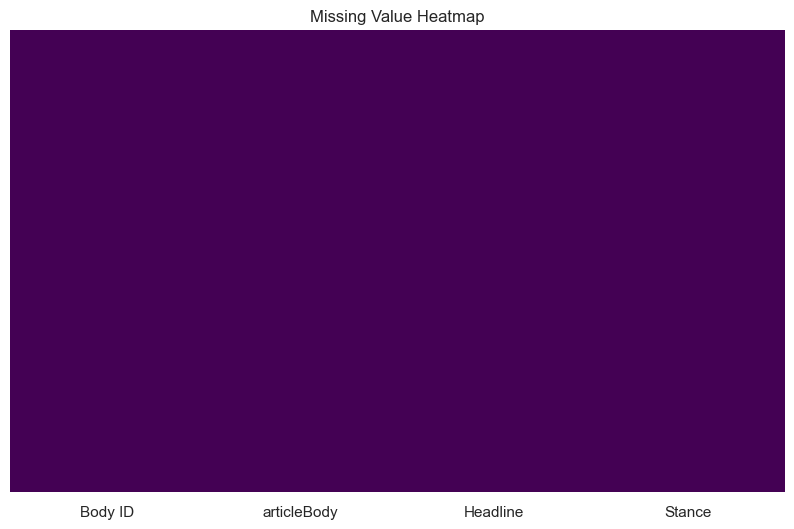

In [3]:
# Visualisasi: Missing value heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()


**Insight Singkat:**
(Isi dengan hasil pengamatan Anda dari overview data, seperti fitur dominan yang berupa string dan seberapa banyak data yang kita miliki).


## Analisis Data Null


,Missing Values,Percentage (%)
Body ID,0,0.0
articleBody,0,0.0
Headline,0,0.0
Stance,0,0.0


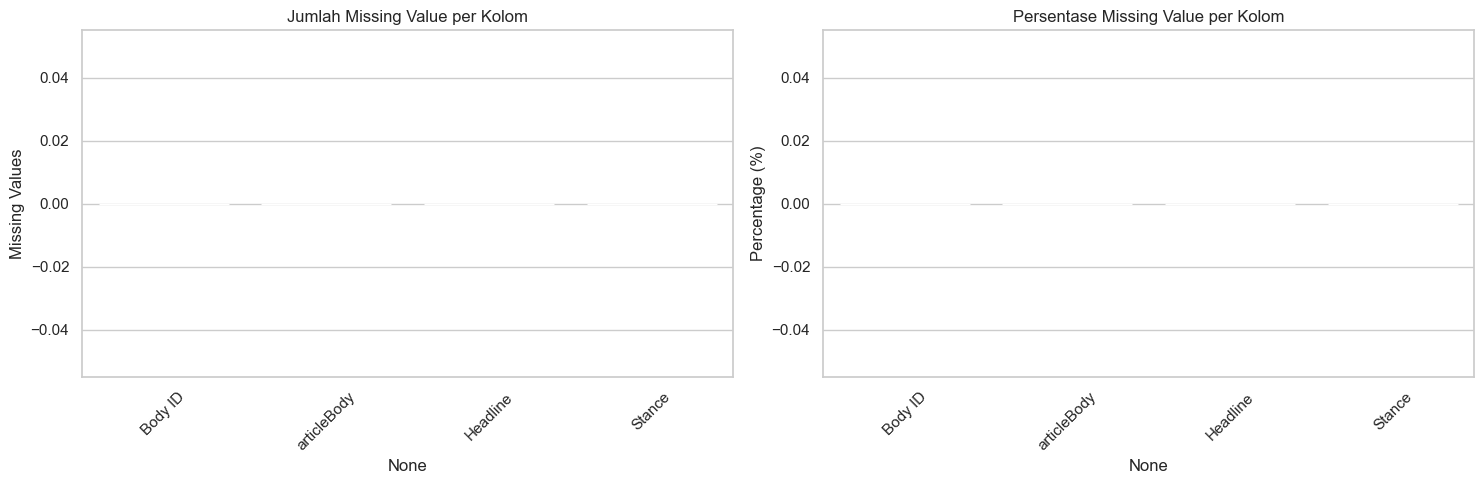

In [4]:
# Missing value per kolom dan persentase
null_counts = df.isnull().sum()
null_percentages = 100 * null_counts / len(df)
null_df = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_percentages})
display(null_df)

# Visualisasi: Barplot jumlah & persentase missing value
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=null_df.index, y=null_df['Missing Values'], ax=axes[0], palette='Reds')
axes[0].set_title('Jumlah Missing Value per Kolom')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=null_df.index, y=null_df['Percentage (%)'], ax=axes[1], palette='Reds')
axes[1].set_title('Persentase Missing Value per Kolom')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Insight Singkat:**
(Tuliskan apakah ada kolom yang kehilangan banyak data atau apakah dataset cukup bersih dari nilai null).


## Analisis Data Duplikat


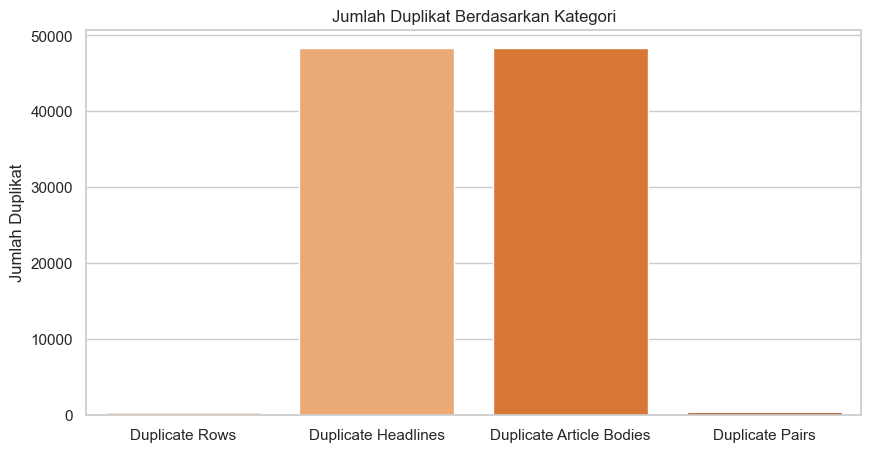


Contoh Exact Duplicate Row:


,Body ID,articleBody,Headline,Stance
47,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated
54,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated



Contoh Duplicate Headline (beda body/stance):


,Body ID,articleBody,Headline,Stance
4161,239,Holy Motor City gossip! The rumored theft of t...,"""Categorically False"": DHS Debunks Right-Wing ...",unrelated
44317,2296,North Korean despot Kim Jong-un has been guzzl...,"""Categorically False"": DHS Debunks Right-Wing ...",unrelated



Contoh Duplicate Article Body (beda headline/stance):


,Body ID,articleBody,Headline,Stance
9148,560,"""As if"" we needed another.\n\nUPDATED: OK, we’...","No, That Wasn’t Paul Rudd Tackling an Airport ...",agree
9149,560,"""As if"" we needed another.\n\nUPDATED: OK, we’...","Whoa, Paul Rudd Was One of the Airport Heroes ...",disagree


In [5]:
# Periksa duplikat
dup_row = df.duplicated().sum()
dup_headline = df['Headline'].duplicated().sum() if 'Headline' in df.columns else 0
dup_body = df['articleBody'].duplicated().sum() if 'articleBody' in df.columns else 0

# Duplicate pair (Headline + Body)
if 'Headline' in df.columns and 'articleBody' in df.columns:
    dup_pair = df.duplicated(subset=['Headline', 'articleBody']).sum()
else:
    dup_pair = 0

dup_stats = {
    'Duplicate Rows': dup_row,
    'Duplicate Headlines': dup_headline,
    'Duplicate Article Bodies': dup_body,
    'Duplicate Pairs': dup_pair
}

# Visualisasi Barplot
plt.figure(figsize=(10, 5))
sns.barplot(x=list(dup_stats.keys()), y=list(dup_stats.values()), palette='Oranges')
plt.title('Jumlah Duplikat Berdasarkan Kategori')
plt.ylabel('Jumlah Duplikat')
plt.show()

# Menampilkan contoh data duplikat jika ada
if dup_row > 0:
    print("\nContoh Exact Duplicate Row:")
    display(df[df.duplicated(keep=False)].head(2))

if dup_headline > 0:
    print("\nContoh Duplicate Headline (beda body/stance):")
    display(df[df.duplicated(subset=['Headline'], keep=False)].sort_values('Headline').head(2))

if dup_body > 0:
    print("\nContoh Duplicate Article Body (beda headline/stance):")
    display(df[df.duplicated(subset=['articleBody'], keep=False)].sort_values('articleBody').head(2))


**Insight Singkat:**
(Analisis apakah duplikasi yang terjadi adalah wajar, misalnya karena satu berita dikaitkan dengan banyak headline yang berbeda).


## Analisis Distribusi Label


,Count,Percentage (%)
Stance,,
unrelated,36545,73.130953
discuss,8909,17.827984
agree,3678,7.360122
disagree,840,1.680941


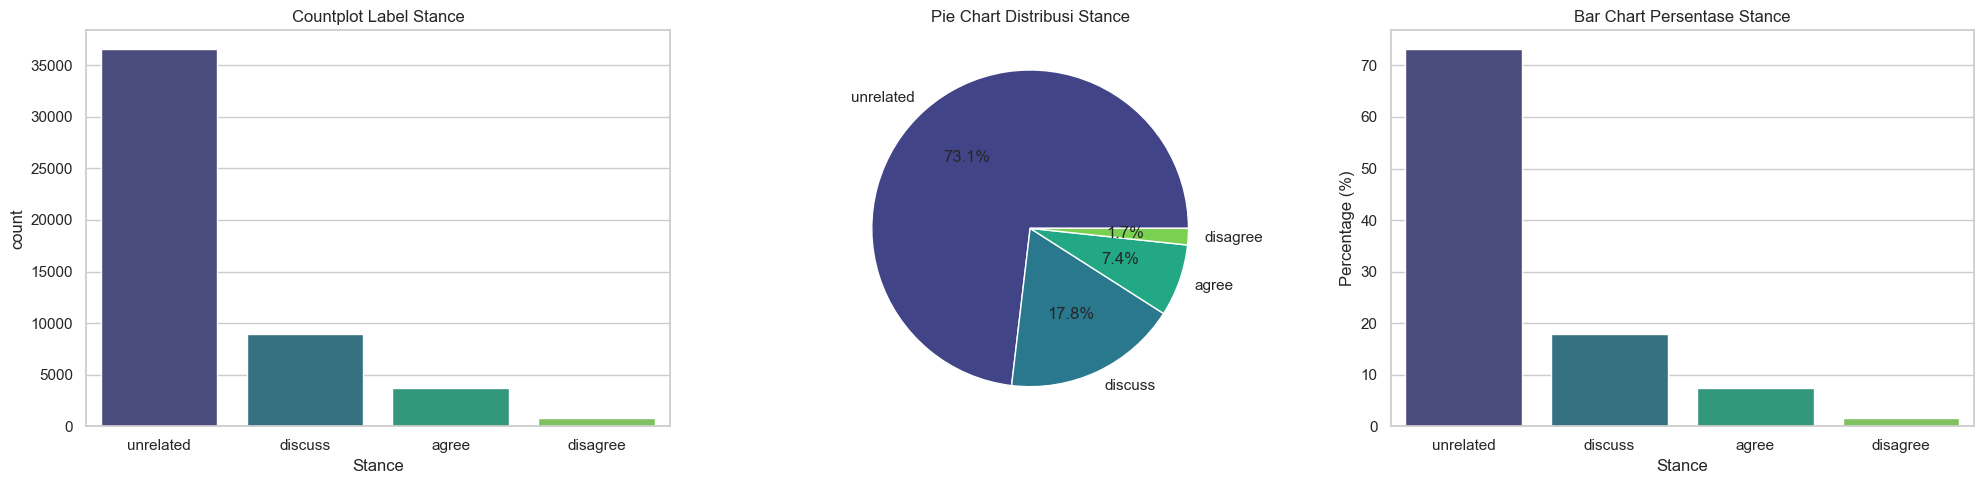

Imbalance Ratio (Max/Min): 43.51


In [6]:
if 'Stance' in df.columns:
    stance_counts = df['Stance'].value_counts()
    stance_percentages = 100 * stance_counts / len(df)
    
    dist_df = pd.DataFrame({'Count': stance_counts, 'Percentage (%)': stance_percentages})
    display(dist_df)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Countplot
    sns.countplot(data=df, x='Stance', order=stance_counts.index, ax=axes[0], palette='viridis')
    axes[0].set_title('Countplot Label Stance')
    
    # 2. Pie chart
    axes[1].pie(stance_counts, labels=stance_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(stance_counts)))
    axes[1].set_title('Pie Chart Distribusi Stance')
    
    # 3. Bar chart persentase
    sns.barplot(x=dist_df.index, y=dist_df['Percentage (%)'], ax=axes[2], palette='viridis')
    axes[2].set_title('Bar Chart Persentase Stance')
    
    plt.tight_layout()
    plt.show()
    
    # Hitung imbalance ratio (Majority class / Minority class)
    imbalance_ratio = stance_counts.max() / stance_counts.min()
    print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")


**Insight Singkat mengenai tingkat class imbalance:**
(Catat apakah data sangat didominasi oleh kelas unrelated dan seberapa parah ketidakseimbangannya).


## Analisis Headline


Statistik Panjang Headline:


,mean,median,min,max,std
Headline_Char_Len,69.356860,65.0,9.0,225.0,24.825253
Headline_Word_Count,11.126471,10.0,2.0,40.0,4.201797


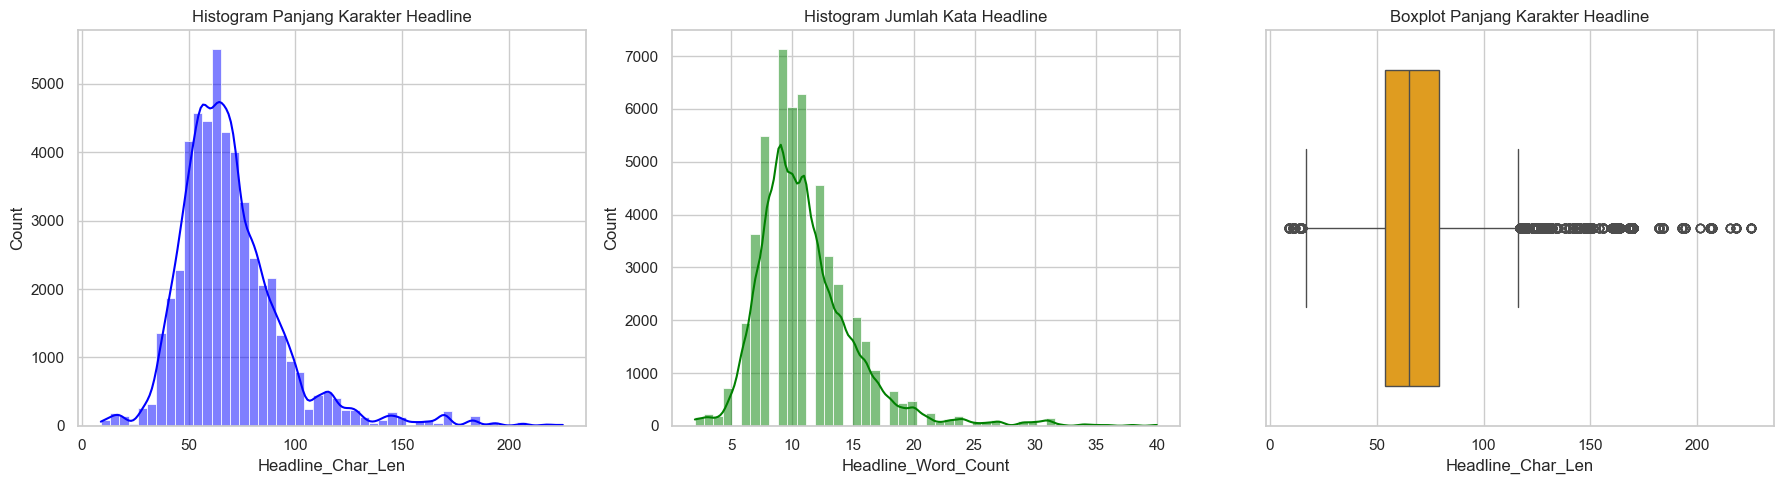

In [7]:
if 'Headline' in df.columns:
    # Mengisi NaN dengan string kosong jika ada
    df['Headline'] = df['Headline'].fillna('')
    
    df['Headline_Char_Len'] = df['Headline'].apply(len)
    df['Headline_Word_Count'] = df['Headline'].apply(lambda x: len(x.split()))
    
    print("Statistik Panjang Headline:")
    display(df[['Headline_Char_Len', 'Headline_Word_Count']].describe().T[['mean', '50%', 'min', 'max', 'std']].rename(columns={'50%':'median'}))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.histplot(df['Headline_Char_Len'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Histogram Panjang Karakter Headline')
    
    sns.histplot(df['Headline_Word_Count'], bins=50, kde=True, ax=axes[1], color='green')
    axes[1].set_title('Histogram Jumlah Kata Headline')
    
    sns.boxplot(x=df['Headline_Char_Len'], ax=axes[2], color='orange')
    axes[2].set_title('Boxplot Panjang Karakter Headline')
    
    plt.tight_layout()
    plt.show()


**Insight Singkat:**
(Analisis variasi panjang headline dan apakah ada headline yang tidak masuk akal panjang atau pendeknya).


=== Statistik Panjang Kata Headline per Kelas ===


,count,mean,std,min,25%,50%,75%,max
Stance,,,,,,,,
agree,3678.0,11.212344,4.154193,2.0,8.0,10.0,13.0,35.0
disagree,840.0,11.092857,4.100170,3.0,9.0,10.0,13.0,35.0
discuss,8909.0,10.866203,4.134994,2.0,8.0,10.0,12.0,40.0
unrelated,36545.0,11.182050,4.222715,2.0,9.0,10.0,13.0,40.0



=== Statistik Panjang Kata Article Body per Kelas ===


,count,mean,std,min,25%,50%,75%,max
Stance,,,,,,,,
agree,3678.0,344.599511,287.995541,4.0,181.25,277.0,412.0,2243.0
disagree,840.0,371.341667,260.741980,10.0,188.00,304.0,498.0,1523.0
discuss,8909.0,402.536312,337.452212,8.0,198.00,326.0,517.0,4788.0
unrelated,36545.0,364.185908,262.586099,8.0,203.00,304.0,457.0,2129.0


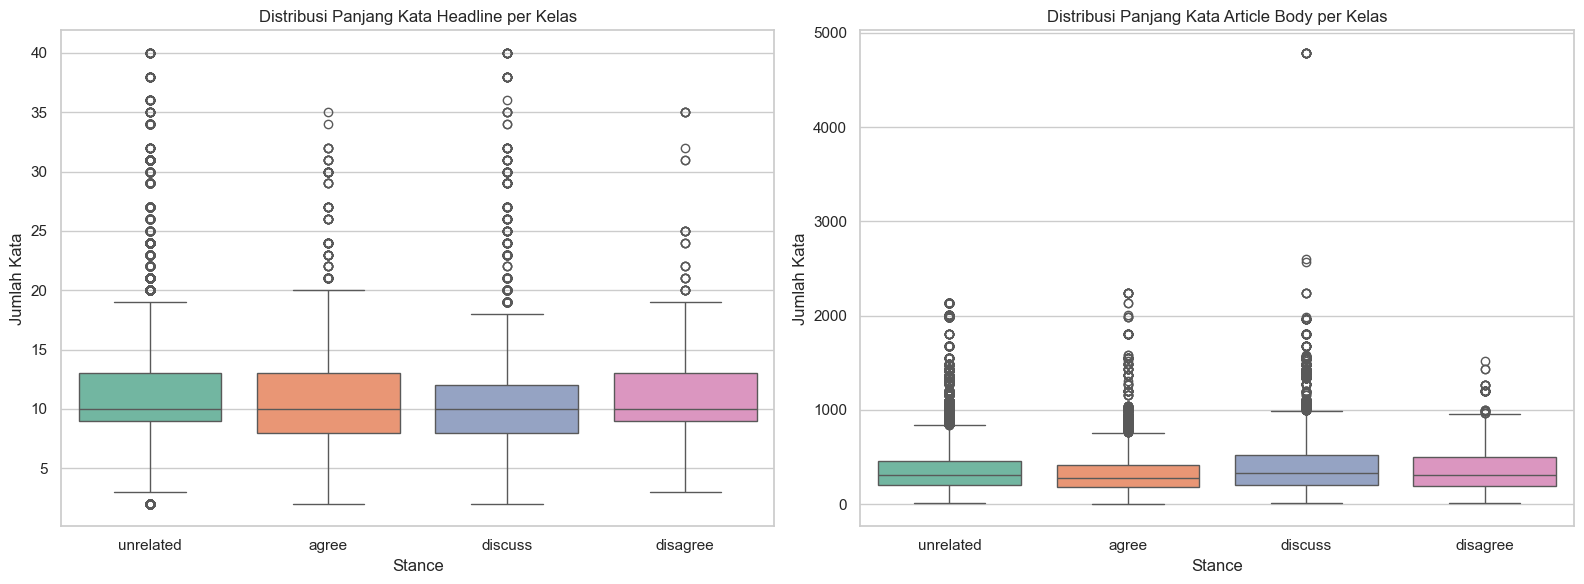

In [15]:
# 1. Menghitung jumlah kata (Word Count) untuk Headline dan Article Body
df['headline_word_count'] = df['Headline'].apply(lambda x: len(str(x).split()))
df['body_word_count'] = df['articleBody'].apply(lambda x: len(str(x).split()))

# 2. Menampilkan Statistik Deskriptif per Kelas
print("=== Statistik Panjang Kata Headline per Kelas ===")
display(df.groupby('Stance')['headline_word_count'].describe())

print("\n=== Statistik Panjang Kata Article Body per Kelas ===")
display(df.groupby('Stance')['body_word_count'].describe())

# 3. Visualisasi Distribusi Panjang Kata menggunakan Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Stance', y='headline_word_count', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Panjang Kata Headline per Kelas')
axes[0].set_xlabel('Stance')
axes[0].set_ylabel('Jumlah Kata')

sns.boxplot(data=df, x='Stance', y='body_word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Panjang Kata Article Body per Kelas')
axes[1].set_xlabel('Stance')
axes[1].set_ylabel('Jumlah Kata')
# Opsional: Membatasi y-axis body_word_count jika terdapat outlier yang sangat ekstrim
# axes[1].set_ylim(0, 2000) 

plt.tight_layout()
plt.show()

## Analisis Article Body


Statistik Panjang Article Body:


,mean,median,min,max,std
Body_Char_Len,2207.547266,1824.0,38.0,27579.0,1676.838550
Body_Word_Count,369.701713,304.0,4.0,4788.0,279.695303


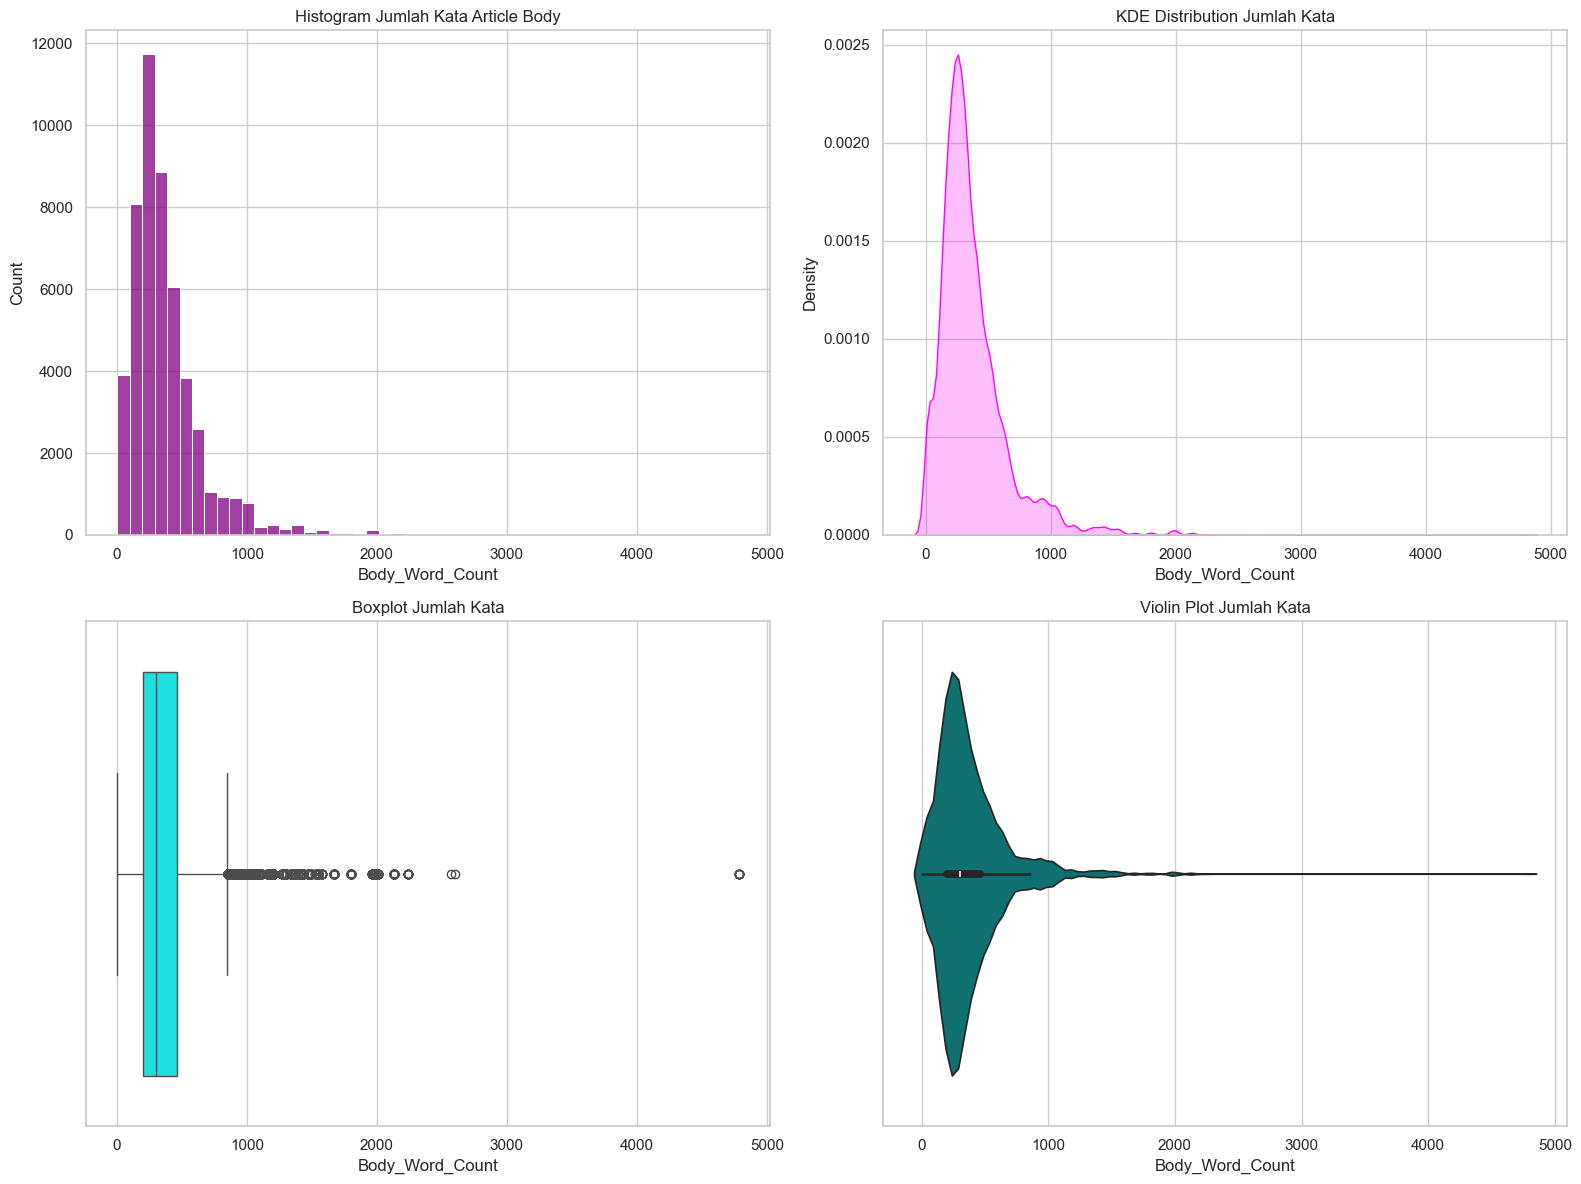

Contoh Outlier (Top 3 artikel terpanjang berdasarkan kata):


,articleBody,Body_Word_Count
23820,Our Retina MacBook Air rumour article brings t...,4788
23821,Our Retina MacBook Air rumour article brings t...,4788
23822,Our Retina MacBook Air rumour article brings t...,4788


In [8]:
if 'articleBody' in df.columns:
    df['articleBody'] = df['articleBody'].fillna('')
    
    df['Body_Char_Len'] = df['articleBody'].apply(len)
    df['Body_Word_Count'] = df['articleBody'].apply(lambda x: len(x.split()))
    
    print("Statistik Panjang Article Body:")
    display(df[['Body_Char_Len', 'Body_Word_Count']].describe().T[['mean', '50%', 'min', 'max', 'std']].rename(columns={'50%':'median'}))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Histogram
    sns.histplot(df['Body_Word_Count'], bins=50, ax=axes[0,0], color='purple')
    axes[0,0].set_title('Histogram Jumlah Kata Article Body')
    
    # 2. KDE
    sns.kdeplot(df['Body_Word_Count'], fill=True, ax=axes[0,1], color='magenta')
    axes[0,1].set_title('KDE Distribution Jumlah Kata')
    
    # 3. Boxplot
    sns.boxplot(x=df['Body_Word_Count'], ax=axes[1,0], color='cyan')
    axes[1,0].set_title('Boxplot Jumlah Kata')
    
    # 4. Violin
    sns.violinplot(x=df['Body_Word_Count'], ax=axes[1,1], color='teal')
    axes[1,1].set_title('Violin Plot Jumlah Kata')
    
    plt.tight_layout()
    plt.show()
    
    # Highlight outlier article
    print("Contoh Outlier (Top 3 artikel terpanjang berdasarkan kata):")
    display(df.sort_values('Body_Word_Count', ascending=False)[['articleBody', 'Body_Word_Count']].head(3))


**Insight Singkat:**
(Sebutkan temuan dari bentuk sebaran artikel body, seperti ekor distribusi yang panjang menandakan adanya outlier sangat panjang).


## Token Distribution Analysis


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (647 > 512). Running this sequence through the model will result in indexing errors


,Mean,Median,P90,P95,P99,Max,> 512,> 1024,> 2048,> 4096
RoBERTa Headline,15.662851,15.0,23.0,26.0,36.00,84.0,0.000000,0.000000,0.000000,0.000000
RoBERTa Body,496.355899,407.0,894.0,1240.0,1891.00,6156.0,35.716001,7.656288,0.786440,0.016009
RoBERTa Combined,511.899724,423.0,914.0,1254.0,1904.29,6182.0,37.969263,7.740335,0.790443,0.016009
XLNet Combined,504.455395,417.0,906.0,1218.0,1881.00,6402.0,37.180821,7.504202,0.576323,0.016009


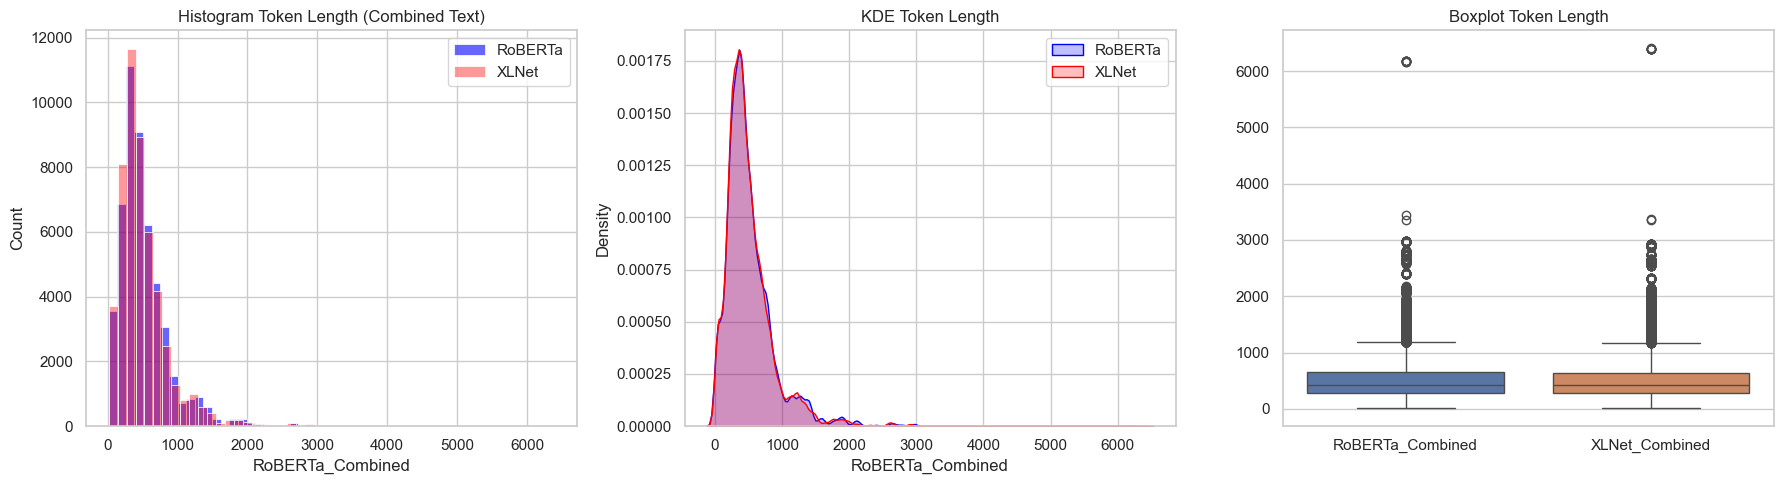

In [9]:
# Meng-load tokenizers
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
xlnet_tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

def count_tokens(text, tokenizer):
    # Menggunakan metode yang cepat untuk menghitung token length (tanpa padding/truncation)
    return len(tokenizer.tokenize(text))

sample_df = df

if 'Headline' in sample_df.columns and 'articleBody' in sample_df.columns:
    sample_df['Combined_Text'] = sample_df['Headline'] + " " + sample_df['articleBody']
    
    # RoBERTa
    sample_df['RoBERTa_Headline'] = sample_df['Headline'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    sample_df['RoBERTa_Body'] = sample_df['articleBody'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    sample_df['RoBERTa_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    
    # XLNet
    sample_df['XLNet_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(str(x), xlnet_tokenizer))
    
    # Buat fungsi ringkasan
    def token_summary(series):
        return {
            'Mean': series.mean(),
            'Median': series.median(),
            'P90': np.percentile(series, 90),
            'P95': np.percentile(series, 95),
            'P99': np.percentile(series, 99),
            'Max': series.max(),
            '> 512': (series > 512).mean() * 100,
            '> 1024': (series > 1024).mean() * 100,
            '> 2048': (series > 2048).mean() * 100,
            '> 4096': (series > 4096).mean() * 100
        }
    
    summary_df = pd.DataFrame({
        'RoBERTa Headline': token_summary(sample_df['RoBERTa_Headline']),
        'RoBERTa Body': token_summary(sample_df['RoBERTa_Body']),
        'RoBERTa Combined': token_summary(sample_df['RoBERTa_Combined']),
        'XLNet Combined': token_summary(sample_df['XLNet_Combined'])
    }).T
    
    display(summary_df)
    
    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.histplot(sample_df['RoBERTa_Combined'], bins=50, ax=axes[0], color='blue', alpha=0.6, label='RoBERTa')
    sns.histplot(sample_df['XLNet_Combined'], bins=50, ax=axes[0], color='red', alpha=0.4, label='XLNet')
    axes[0].set_title('Histogram Token Length (Combined Text)')
    axes[0].legend()
    
    sns.kdeplot(sample_df['RoBERTa_Combined'], fill=True, ax=axes[1], color='blue', label='RoBERTa')
    sns.kdeplot(sample_df['XLNet_Combined'], fill=True, ax=axes[1], color='red', label='XLNet')
    axes[1].set_title('KDE Token Length')
    axes[1].legend()
    
    sns.boxplot(data=sample_df[['RoBERTa_Combined', 'XLNet_Combined']], ax=axes[2])
    axes[2].set_title('Boxplot Token Length')
    
    plt.tight_layout()
    plt.show()



## Token Distribution per Label


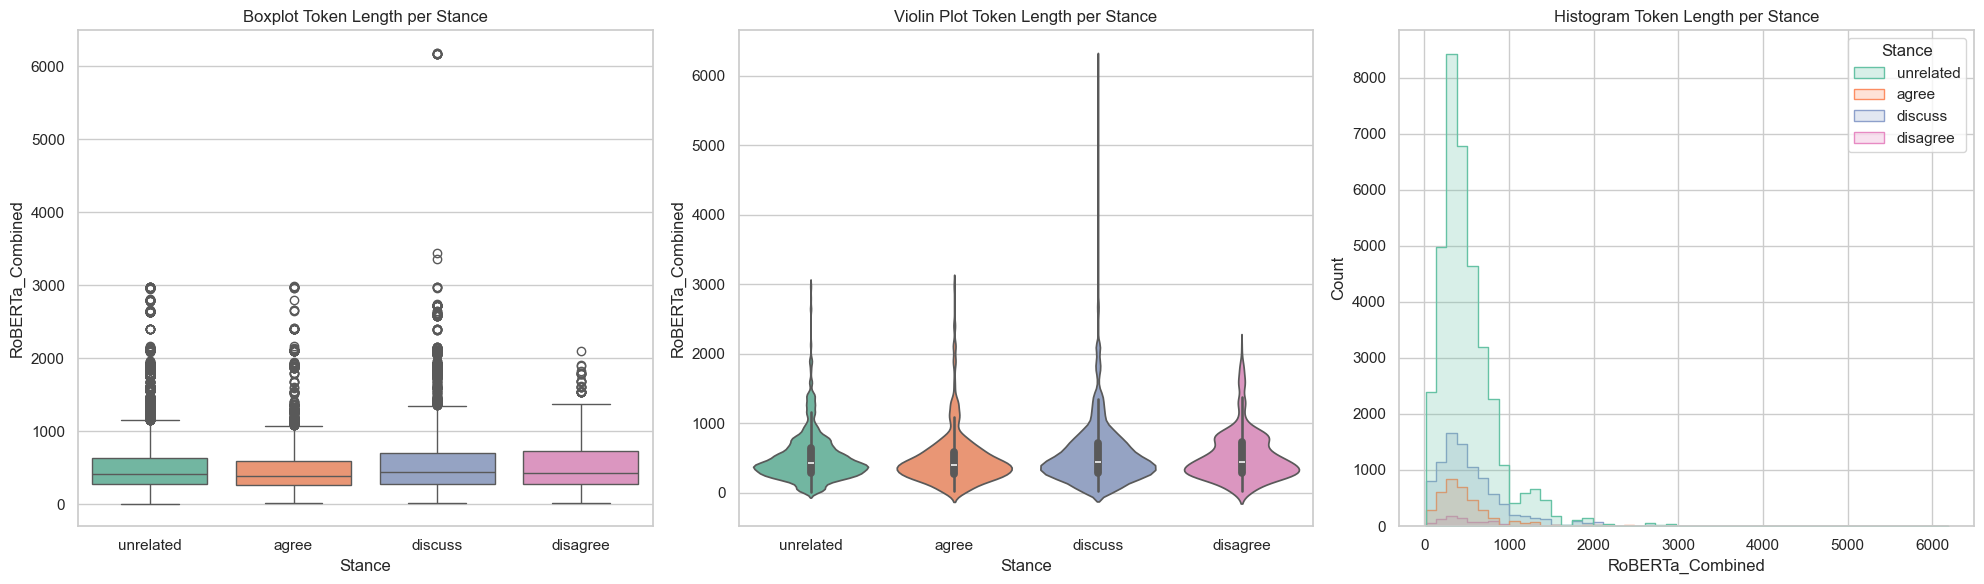

In [10]:
if 'Stance' in sample_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    sns.boxplot(x='Stance', y='RoBERTa_Combined', data=sample_df, ax=axes[0], palette='Set2')
    axes[0].set_title('Boxplot Token Length per Stance')
    
    sns.violinplot(x='Stance', y='RoBERTa_Combined', data=sample_df, ax=axes[1], palette='Set2')
    axes[1].set_title('Violin Plot Token Length per Stance')
    
    sns.histplot(data=sample_df, x='RoBERTa_Combined', hue='Stance', element='step', common_norm=False, ax=axes[2], palette='Set2', bins=50)
    axes[2].set_title('Histogram Token Length per Stance')
    
    plt.tight_layout()
    plt.show()


## Word Frequency Analysis


Memproses teks untuk word frequency...


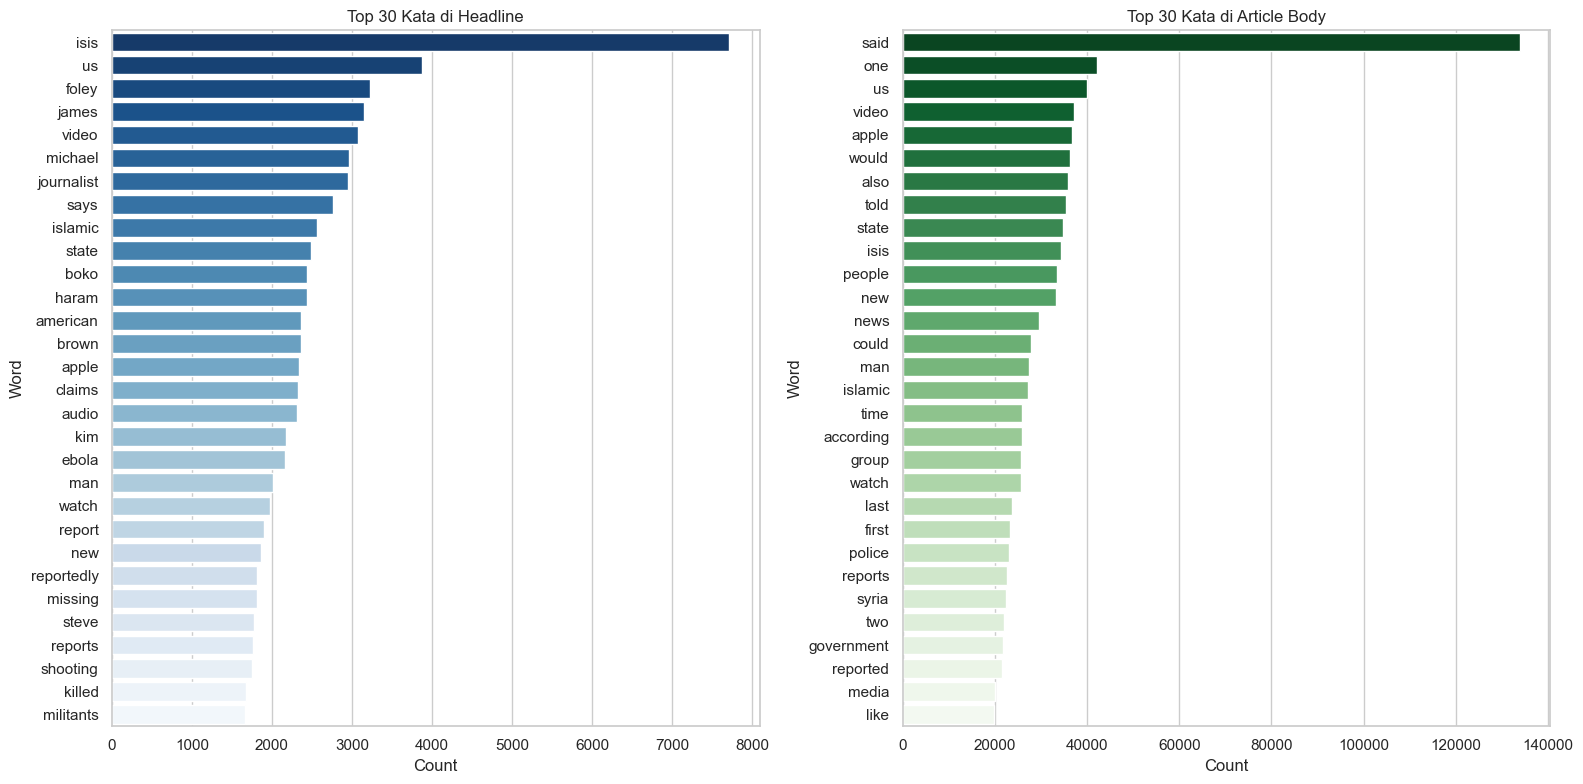

In [11]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase & remove punctuation
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

if 'Headline' in df.columns and 'articleBody' in df.columns:
    print("Memproses teks untuk word frequency...")
    freq_df = df
    
    all_headlines_words = []
    freq_df['Headline'].apply(lambda x: all_headlines_words.extend(preprocess_text(x)))
    
    all_body_words = []
    freq_df['articleBody'].apply(lambda x: all_body_words.extend(preprocess_text(x)))
    
    head_counter = Counter(all_headlines_words).most_common(30)
    body_counter = Counter(all_body_words).most_common(30)
    
    head_df = pd.DataFrame(head_counter, columns=['Word', 'Count'])
    body_df = pd.DataFrame(body_counter, columns=['Word', 'Count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    sns.barplot(data=head_df, y='Word', x='Count', ax=axes[0], palette='Blues_r')
    axes[0].set_title('Top 30 Kata di Headline')
    
    sns.barplot(data=body_df, y='Word', x='Count', ax=axes[1], palette='Greens_r')
    axes[1].set_title('Top 30 Kata di Article Body')
    
    plt.tight_layout()
    plt.show()


## WordCloud Analysis


Wordcloud untuk Seluruh Teks:


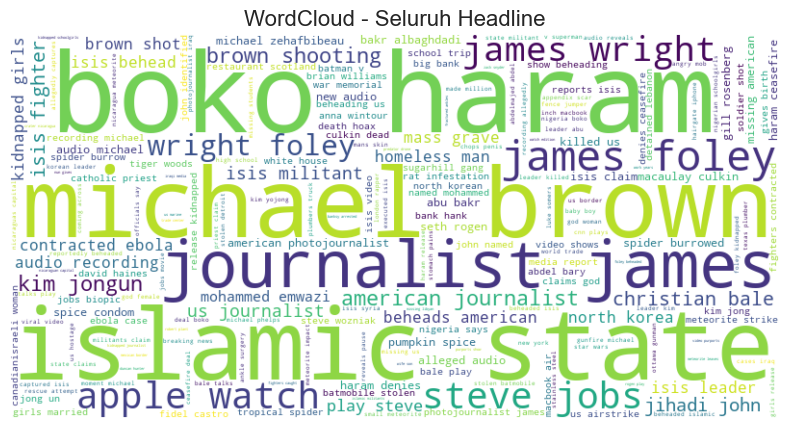

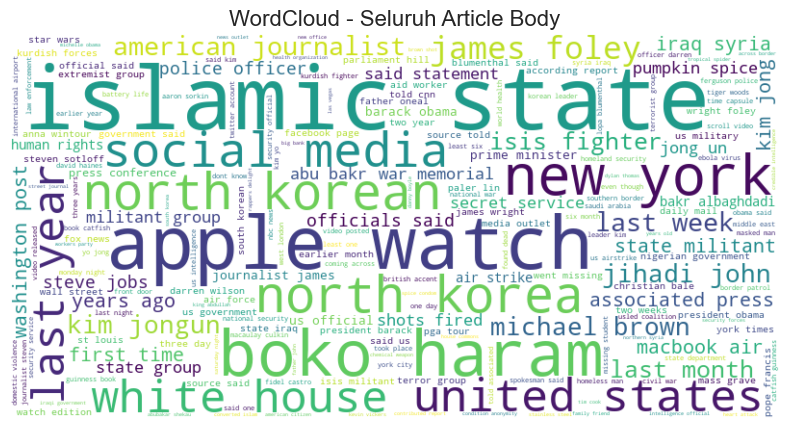

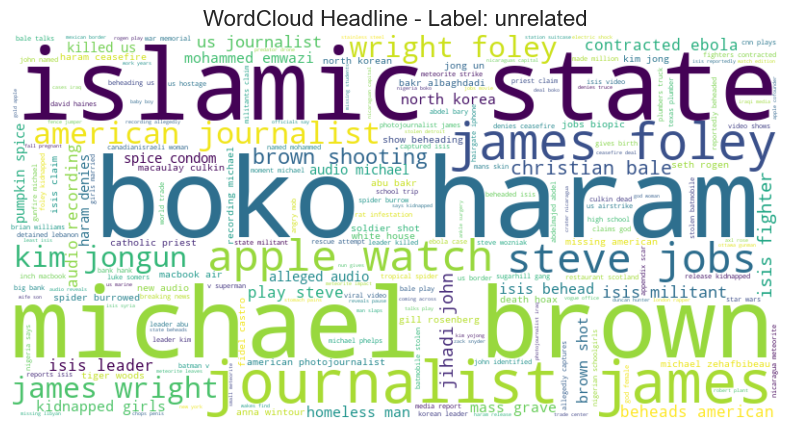

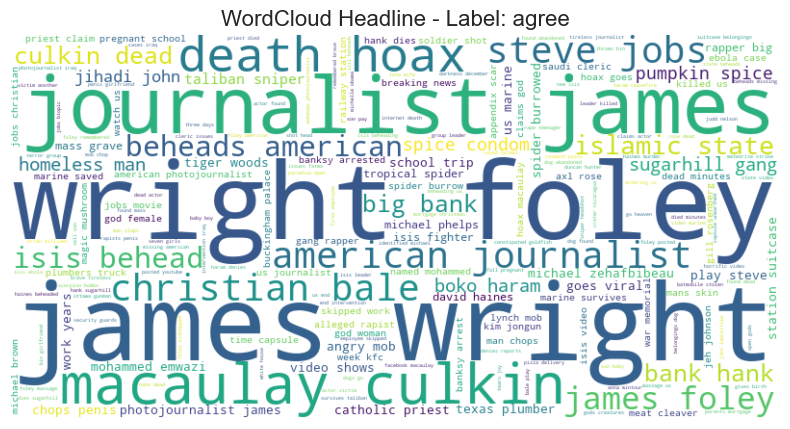

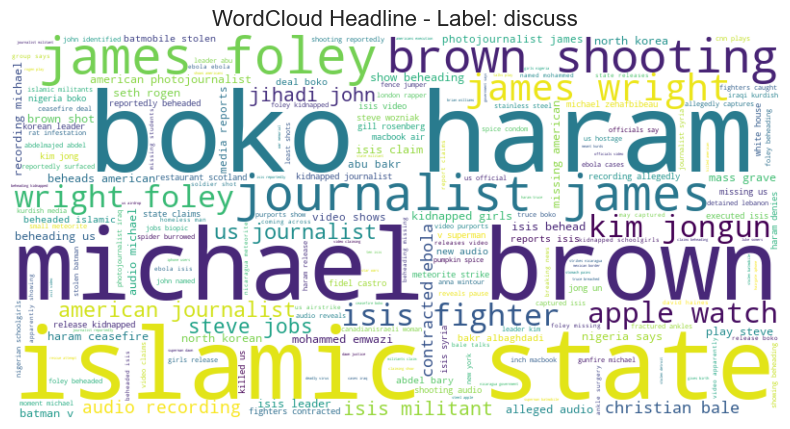

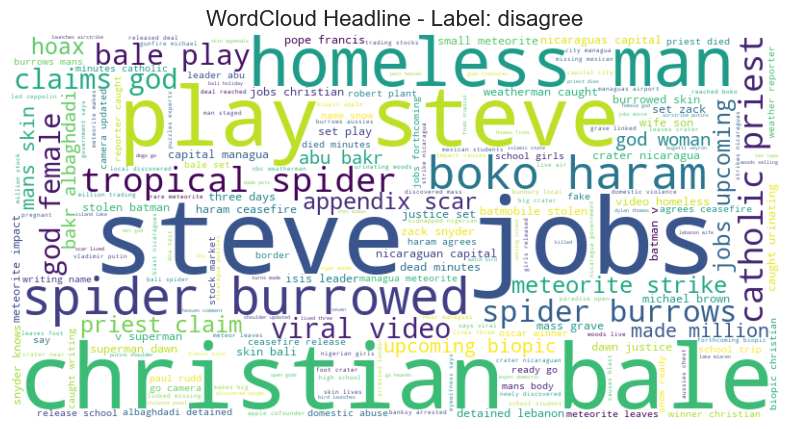

In [12]:
def generate_wordcloud(words_list, title):
    text = ' '.join(words_list)
    if not text.strip(): return
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

if 'Headline' in df.columns and 'articleBody' in df.columns:
    print("Wordcloud untuk Seluruh Teks:")
    generate_wordcloud(all_headlines_words, 'WordCloud - Seluruh Headline')
    generate_wordcloud(all_body_words, 'WordCloud - Seluruh Article Body')
    
    # Wordcloud per label
    if 'Stance' in df.columns:
        stances = df['Stance'].unique()
        for s in stances:
            subset = df[df['Stance'] == s]
            words = []
            subset['Headline'].apply(lambda x: words.extend(preprocess_text(x)))
            generate_wordcloud(words, f'WordCloud Headline - Label: {s}')


## Text Quality Analysis


In [14]:
import re
import pandas as pd

# 1. Definisikan pola regex di luar fungsi agar lebih efisien (hanya di-compile sekali)
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')

# 2. Fungsi check_quality
def check_quality(text):
    if not isinstance(text, str):
        return pd.Series([False, False, False, False, False])
        
    has_url = bool(url_pattern.search(text))
    has_html = bool(html_pattern.search(text))
    has_email = bool(email_pattern.search(text))
    has_unicode = bool(unicode_pattern.search(text))
    has_multiple_ws = bool(multiple_ws_pattern.search(text))
    
    return pd.Series([has_url, has_html, has_email, has_unicode, has_multiple_ws])

# 3. Proses datanya
if 'articleBody' in df.columns:
    qual_df = df['articleBody'].apply(check_quality)
    qual_df.columns = ['URL', 'HTML', 'Email', 'UnicodeAneh', 'MultipleWhitespace']
    
    qual_sums = qual_df.sum()
    print(qual_sums)

URL                    1791
HTML                    284
Email                  3389
UnicodeAneh           33002
MultipleWhitespace    45417
dtype: int64


**Insight Singkat:**
(Review apakah teks membutuhkan pembersihan ekstra dari HTML, URL, atau karakter non-ASCII).


## Model Selection Insight


Berdasarkan hasil "Token Distribution Analysis" di atas, kita dapat merangkum metrik berikut:

| Metric | Value |
|----------|----------|
| Avg Token | *[Lihat tabel ringkasan Token Analysis]* |
| Median Token | *[Lihat tabel ringkasan]* |
| P95 Token | *[Lihat tabel ringkasan]* |
| P99 Token | *[Lihat tabel ringkasan]* |
| Max Token | *[Lihat tabel ringkasan]* |
| % > 512 | *[Lihat tabel ringkasan]* |
| % > 1024 | *[Lihat tabel ringkasan]* |
| % > 2048 | *[Lihat tabel ringkasan]* |

### Rekomendasi:
1. **Apakah RoBERTa layak digunakan?**
   - RoBERTa memiliki batas maksimum 512 token. Jika *persentase data > 512 token* tergolong besar (misalnya di atas 10-15%), memotong (truncate) teks bisa menghilangkan informasi penting dari akhir artikel. Jika persentase di atas 512 sangat kecil, RoBERTa sangat direkomendasikan.

2. **Apakah XLNet layak digunakan?**
   - XLNet pada teorinya tidak dibatasi panjang urutan teks layaknya model BERT-based tradisional. Namun, komputasinya akan meledak secara kuadratik dan bisa membutuhkan memori (VRAM) yang luar biasa besar untuk artikel dengan ribuan kata. XLNet layak jika rentang token rata-rata masih dalam batas toleransi VRAM (misal <= 1024).

3. **Apakah Longformer diperlukan?**
   - Longformer (atau BigBird) sangat direkomendasikan jika `P95 Token` atau `% > 512` dan `% > 1024` bernilai sangat signifikan, karena arsitekturnya didesain khusus memproses teks panjang hingga 4096 token dengan *sparse attention*.

4. **Tantangan Terbesar: Token Length vs Class Imbalance**
   - Kombinasi panjang token ekstrim dan *class imbalance* (dengan dominasi `unrelated`) akan mengakibatkan model cepat _overfit_ menebak mayoritas kelas. Oleh karena itu, strategi *undersampling*/*oversampling* atau kalkulasi *class weights* di *Loss Function* wajib digunakan apa pun jenis arsitektur model transformer yang dipilih.

